# Classification Project: Online Shoppers Purchasing Intention
## Notebook 4: Class Balancing Methodology and Experimental Comparison

This notebook compares several class-balancing strategies for the dataset's 85/15 class imbalance.

To isolate the effect of sampling, the classifier is kept fixed to the selected XGBoost configuration. Each sampling strategy is evaluated with 5-fold stratified cross-validation on the training set, using Macro F1 and the minority-class precision/recall as diagnostics.

### Techniques Evaluated:
1. **Baseline (None):** no balancing applied.
2. **Random Under-Sampling (RUS):** randomly removes majority-class instances until classes are equal.
3. **Random Over-Sampling (ROS):** randomly duplicates minority-class instances.
4. **SMOTE (1.0):** generates synthetic minority instances to reach full class balance.
5. **SMOTE (0.7):** generates synthetic instances to reach a 70/100 minority-to-majority ratio.
6. **ADASYN:** generates synthetic data based on the local density of minority-class examples, focusing on harder cases.


In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.base import BaseSampler
from sklearn.neighbors import LocalOutlierFactor
from joblib import parallel_backend
import json

print("--- 1. LOADING D_TRAIN ---")
# Notebooks are executed with the working directory set to the jupyter folder.
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..')) 

file_path = os.path.join(parent_dir, 'online_shoppers_intention.csv')

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Cannot find the dataset at {file_path}")
else:
    df = pd.read_csv(file_path).dropna().reset_index(drop=True)
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)
    df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

    X = df.drop(columns=['Revenue', 'Region'])
    y = df['Revenue']

    from sklearn.model_selection import train_test_split
    # We evaluate exclusively on D_train to preserve the integrity of D_test
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print(f"Training data ready: {X_train.shape[0]} samples.")

--- 1. LOADING D_TRAIN ---
Training data ready: 9864 samples.


In [2]:
# Load the shared LOF_Sampler utility (single source of truth for all notebooks).
%run utils/lof_sampler.py

LOF_Sampler loaded from utils/lof_sampler.py


### 2. Experimental Execution
We define a dictionary of samplers. For each sampler, we construct an `imblearn` pipeline consisting of:
`LOF_Sampler -> StandardScaler -> [Selected Sampler] -> XGBoost`

*Note: The Baseline pipeline simply omits the sampling step.*

In [3]:
print("--- 2. EXECUTING SAMPLING EXPERIMENTS ---")

# Define the samplers to test
samplers = {
    "Baseline (No Balancing)": "passthrough",
    "Under-Sampling (RUS)": RandomUnderSampler(random_state=42),
    "Over-Sampling (ROS)": RandomOverSampler(random_state=42),
    "SMOTE (Ratio 1.0)": SMOTE(random_state=42, sampling_strategy=1.0),
    "SMOTE (Ratio 0.7)": SMOTE(random_state=42, sampling_strategy=0.7),
    "ADASYN": ADASYN(random_state=42)
}

# Define the fixed, optimized XGBoost classifier from Notebook 2 metadata.
metadata_path = os.path.join(parent_dir, 'models', 'model_metadata.json')
with open(metadata_path) as f:
    metadata = json.load(f)
best_params = metadata['best_params']

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    learning_rate=float(best_params['classifier__learning_rate']),
    max_depth=int(best_params['classifier__max_depth']),
    n_estimators=int(best_params['classifier__n_estimators'])
)

# Define robust scoring metrics
scoring = {
    'macro_f1': make_scorer(f1_score, average='macro', zero_division=0),
    'minority_recall': make_scorer(recall_score, pos_label=1, zero_division=0),
    'minority_precision': make_scorer(precision_score, pos_label=1, zero_division=0)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("Running 5-Fold Cross-Validation for each technique. Please wait...\n")

for name, sampler in samplers.items():
    print(f"Evaluating: {name}...")
    
    # Build the dynamic pipeline
    if sampler == "passthrough":
        pipeline = ImbPipeline([
            ('lof', LOF_Sampler(n_neighbors=100, contamination=0.05)),
            ('scaler', StandardScaler()),
            ('classifier', xgb_model)
        ])
    else:
        pipeline = ImbPipeline([
            ('lof', LOF_Sampler(n_neighbors=100, contamination=0.05)),
            ('scaler', StandardScaler()),
            ('sampler', sampler),
            ('classifier', xgb_model)
        ])
        
    # Execute Cross-Validation
    with parallel_backend('threading'):
        cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    
    # Store results
    results.append({
        'Strategy': name,
        'Macro F1': cv_scores['test_macro_f1'].mean(),
        'Recall (Purchase)': cv_scores['test_minority_recall'].mean(),
        'Precision (Purchase)': cv_scores['test_minority_precision'].mean()
    })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)
print("\n--- EXPERIMENT RESULTS ---")
print(results_df.to_string(index=False))

--- 2. EXECUTING SAMPLING EXPERIMENTS ---
Running 5-Fold Cross-Validation for each technique. Please wait...

Evaluating: Baseline (No Balancing)...


Evaluating: Under-Sampling (RUS)...


Evaluating: Over-Sampling (ROS)...


Evaluating: SMOTE (Ratio 1.0)...


Evaluating: SMOTE (Ratio 0.7)...


Evaluating: ADASYN...



--- EXPERIMENT RESULTS ---
               Strategy  Macro F1  Recall (Purchase)  Precision (Purchase)
Baseline (No Balancing)  0.799844           0.597638              0.728196
   Under-Sampling (RUS)  0.778768           0.859111              0.521026
    Over-Sampling (ROS)  0.783456           0.838781              0.535299
      SMOTE (Ratio 1.0)  0.808456           0.763435              0.619298
      SMOTE (Ratio 0.7)  0.814706           0.751645              0.641397
                 ADASYN  0.803258           0.776539              0.599913


### 3. Visualizing the Impact of Class Balancing
We plot the results to visually demonstrate the trade-off between Precision and Recall that occurs when manipulating the class distribution.

--- 3. VISUALIZING METHODOLOGY COMPARISON ---


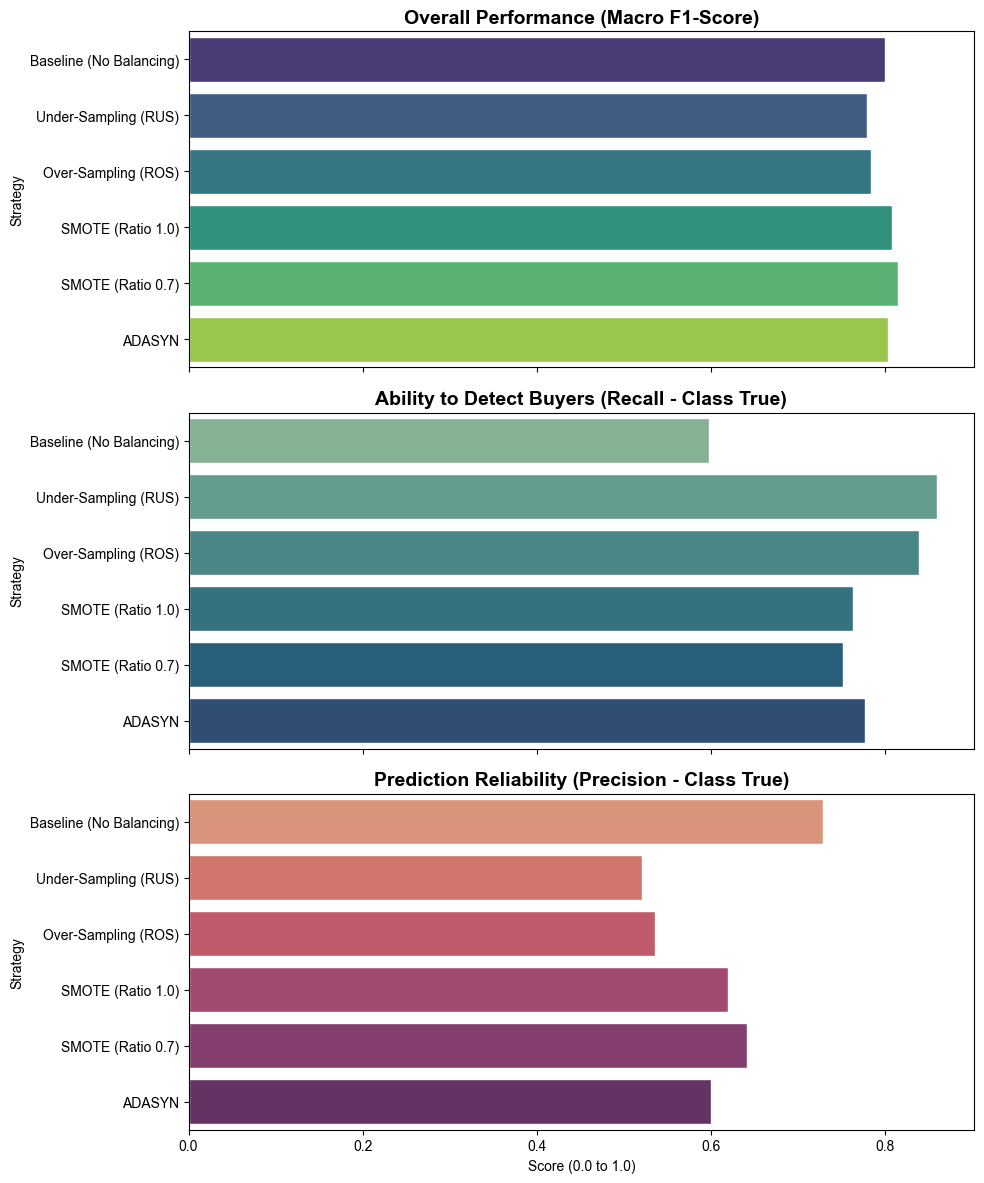


EXPECTED OBSERVATIONS FOR YOUR PRESENTATION:
1. Baseline (No Balancing): High Precision, very low Recall. The model under-detects the minority class.
2. Under-Sampling (RUS): High Recall, but weak Precision. Removing many majority-class examples reduces the model's ability to recognize non-buyers.
3. SMOTE (0.7): Achieves the highest Macro F1 in this experiment by balancing Precision and Recall more effectively than the alternatives.


In [4]:
print("--- 3. VISUALIZING METHODOLOGY COMPARISON ---")

# Set up the matplotlib figure
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
sns.set_theme(style="whitegrid")

# Plot 1: Macro F1-Score (The overall balancing metric)
sns.barplot(
    x='Macro F1', y='Strategy', data=results_df, ax=axes[0], 
    hue='Strategy', palette='viridis', orient='h', legend=False
)
axes[0].set_title('Overall Performance (Macro F1-Score)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')

# Plot 2: Minority Recall (Ability to find all actual buyers)
sns.barplot(
    x='Recall (Purchase)', y='Strategy', data=results_df, ax=axes[1], 
    hue='Strategy', palette='crest', orient='h', legend=False
)
axes[1].set_title('Ability to Detect Buyers (Recall - Class True)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

# Plot 3: Minority Precision (Accuracy when predicting a purchase)
sns.barplot(
    x='Precision (Purchase)', y='Strategy', data=results_df, ax=axes[2], 
    hue='Strategy', palette='flare', orient='h', legend=False
)
axes[2].set_title('Prediction Reliability (Precision - Class True)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score (0.0 to 1.0)')

plt.tight_layout()
plt.show()

print("\nEXPECTED OBSERVATIONS FOR YOUR PRESENTATION:")
print("1. Baseline (No Balancing): High Precision, very low Recall. The model under-detects the minority class.")
print("2. Under-Sampling (RUS): High Recall, but weak Precision. Removing many majority-class examples reduces the model's ability to recognize non-buyers.")
print("3. SMOTE (0.7): Achieves the highest Macro F1 in this experiment by balancing Precision and Recall more effectively than the alternatives.")

---
### 4. Connection to the Main Pipeline

These experiments support the SMOTE configuration used in Notebook 2 (`sampling_strategy=0.7`).

SMOTE with a moderate oversampling ratio (`0.7`) gives the best Macro F1 in this comparison. It improves minority-class recall without the larger precision drop observed with random oversampling or full class balancing (`1.0`). This result is used to keep the `smote__sampling_strategy` search space in the nested CV grid to `[0.7, 1.0]`.

**Context within the full workflow:**
- **Notebook 1** inspects the dataset and feature relationships.
- **Notebook 2** builds and tunes the full pipeline with nested CV.
- **Notebook 3** evaluates the selected pipeline on the locked hold-out set and adds SHAP/LIME explanations.
- **Notebook 4** documents the comparison behind the SMOTE ratio choice.